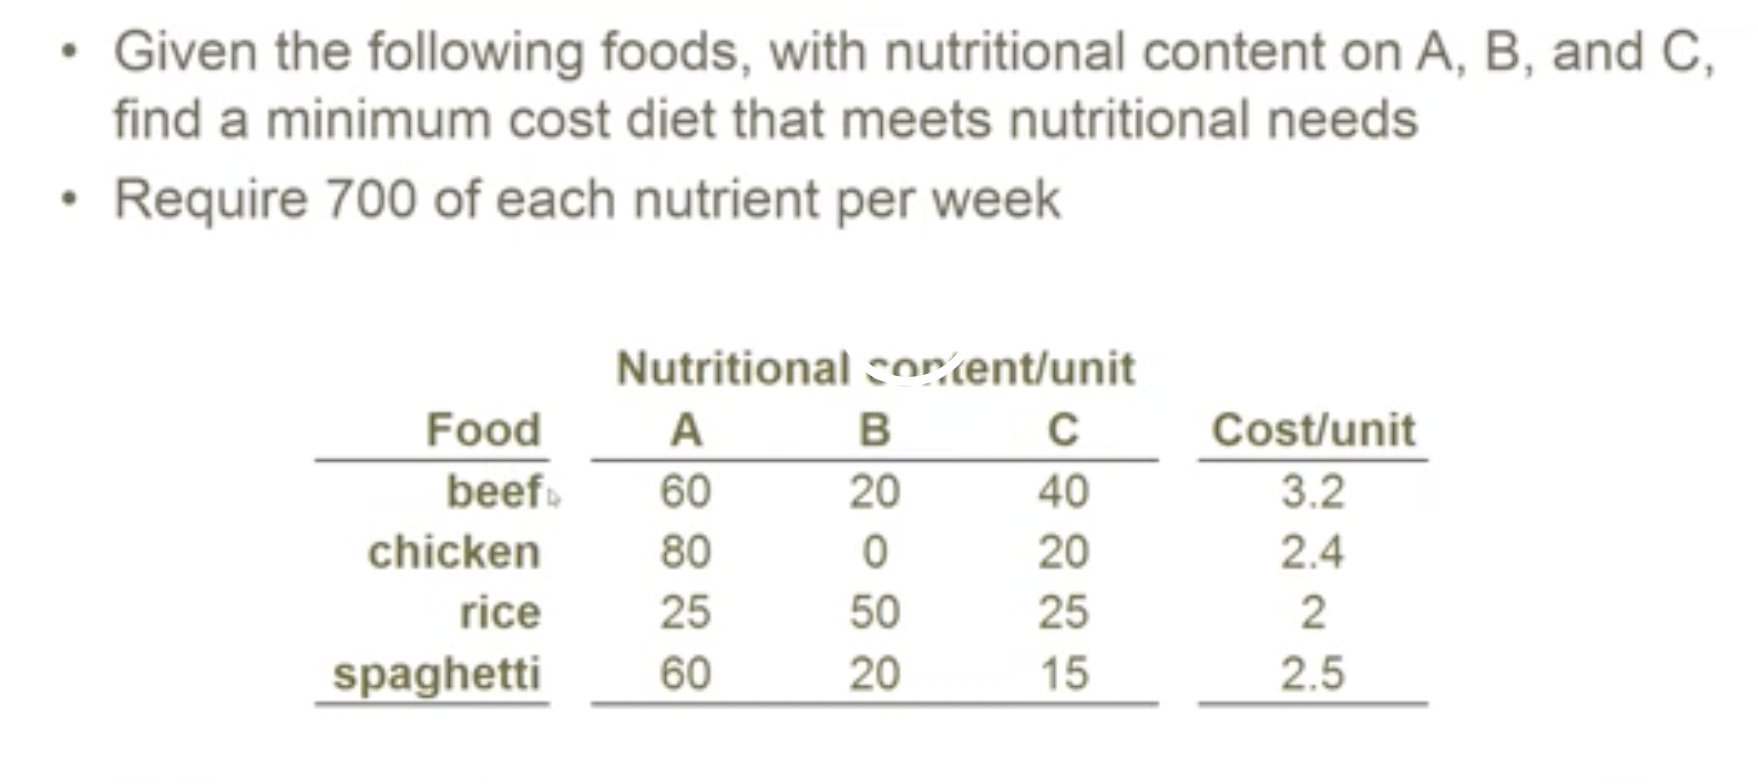

In [80]:
# This version builds a more generic model, in which the data are given in lists.

In [81]:
# First we define the sets of foods and nutrients
Foods = ['beef', 'chicken', 'rice', 'spaghetti']
Nutrients = ['A', 'B', 'C']

# The unit cost can be defined as a 'dictionary' over the Foods:
Cost = {
    'beef' : 3.2,
    'chicken' : 2.4,
    'rice' : 2,
    'spaghetti' : 2.5
}

# Likewise, the nutritional content can be defined as a dictionary (Plants x Nutrients):
Nutrition = {
    ('beef', 'A') : 60,
    ('beef', 'B') : 20,
    ('beef', 'C') : 40,
    ('chicken', 'A') : 80,
    ('chicken', 'B') : 0,
    ('chicken', 'C') : 20,
    ('rice', 'A') : 25,
    ('rice', 'B') : 50,
    ('rice', 'C') : 25,
    ('spaghetti', 'A') : 60,
    ('spaghetti', 'B') : 20,
    ('spaghetti', 'C') : 15,
}

In [82]:
from docplex.mp.model import Model
from docplex.util.environment import get_environment
mdl = Model()

In [83]:
# Define the set of variables amount[i] for all foods i. 
# This can be done directly by defining a 'dictionary' of variables,
# where we use 'Foods' as key.
amount = mdl.continuous_var_dict(Foods, lb=0, name=Foods)

In [84]:
# Since both the variables and the costs are defined over the 
# same key 'Foods' we can compactly define the ojective function as follows: 
objective = mdl.sum(amount[f]*Cost[f] for f in Foods)
mdl.minimize(objective)

In [85]:
for n in Nutrients:
    mdl.add_constraint(mdl.sum(amount[f]*Nutrition[(f,n)] for f in Foods) >= 700)

In [86]:
mdl.solve()
mdl.get_solve_details()

docplex.mp.SolveDetails(time=0.00216699,status='optimal')

In [87]:
mdl.print_solution()

objective: 56.000
status: OPTIMAL_SOLUTION(2)
  beef=11.667
  rice=9.333


In [88]:
mdl.print_solution()

objective: 56.000
status: OPTIMAL_SOLUTION(2)
  beef=11.667
  rice=9.333
